## Classify image

In [ ]:
 #! python 3.10.8
# pip install tensorflow==2.12.1 
# pip install matplotlib pillow
# pip install "numpy<2.0,>=1.26"

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
# The class names must be in the same order as they were during training.
# Check the output of the training script to be sure.
# Usually, it's alphabetical: ['gambling', 'not_gambling']
CLASS_NAMES = ['gambling', 'not_gambling']
MODEL_PATH = './weight/gambling_classifier_mobilenetv2_gemini_150_ep_Augment.h5'


In [ ]:
# --- 2. LOAD THE SAVED MODEL ---
print(f"Loading model from {MODEL_PATH}...")
try:
    model = tf.keras.models.load_model(MODEL_PATH)
except Exception as e:
    print(f"Error loading model: {e}")
    exit()

print("Model loaded successfully.")


Loading model from ./weight/gambling_classifier_mobilenetv2_gemini_150_ep_Augment.h5...
Model loaded successfully.


In [ ]:
# --- 3. CREATE A PREDICTION FUNCTION ---
# This function prepares a single image and makes a prediction.
def predict_image(image_path, model):
    """Loads an image, preprocesses it, and returns the prediction."""
    print(f"\nPredicting image: {image_path}")
    
    img = tf.keras.utils.load_img(
        image_path, target_size=(IMG_HEIGHT, IMG_WIDTH)
    )
    
    # Convert the image to a NumPy array
    img_array = tf.keras.utils.img_to_array(img)
    
    # The model expects a "batch" of images, so we add an extra dimension
    img_array = tf.expand_dims(img_array, 0)  # Create a batch

    # Make the prediction
    predictions = model.predict(img_array)
    score = predictions[0][0] # Get the single prediction value from the batch

    # Interpret the prediction
    # The sigmoid function outputs a value between 0 and 1.
    # We'll use 0.5 as the threshold to decide the class.
    # IMPORTANT: The index (0 or 1) depends on the class order.
    # If CLASS_NAMES = ['gambling', 'not_gambling']:
    #   - A low score (close to 0) means it's the first class ('gambling').
    #   - A high score (close to 1) means it's the second class ('not_gambling').
    
    confidence = 1 - score if score < 0.5 else score
    predicted_class = CLASS_NAMES[0] if score < 0.5 else CLASS_NAMES[1]
    # Show image with label
    plt.imshow(img)  # use PIL Image (already resized)
    plt.axis("off")
    plt.title(f"{predicted_class} ({confidence:.1%})", fontsize=12, color="blue")
    plt.show()
    
    return predicted_class, confidence



Predicting image: ../for_test/A20241001001.png
1/1 [==============================] - 0s 59ms/step


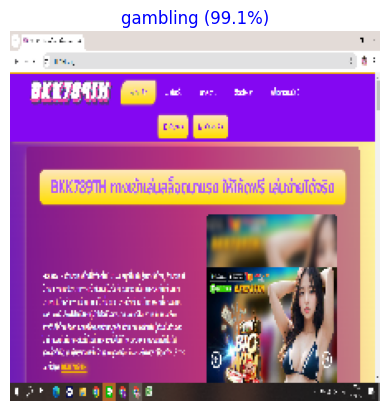


Predicting image: ../for_test/A20241001002.png
1/1 [==============================] - 0s 47ms/step


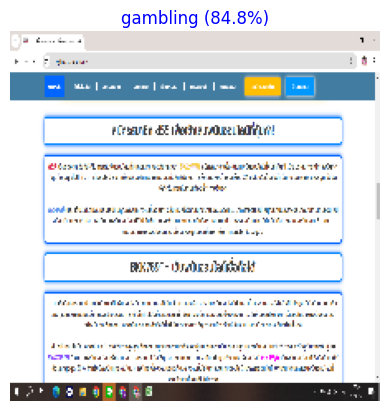


Predicting image: ../for_test/ufa-ball.png
1/1 [==============================] - 0s 36ms/step


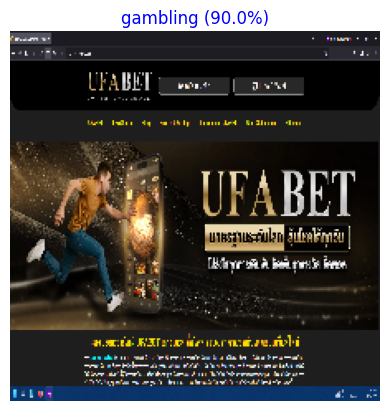


Predicting image: ../for_test/de.png
1/1 [==============================] - 0s 34ms/step


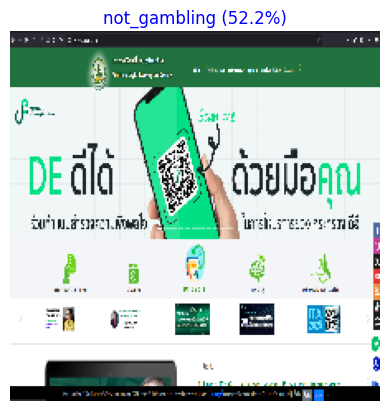


Predicting image: ../for_test/kaggle.png
1/1 [==============================] - 0s 41ms/step


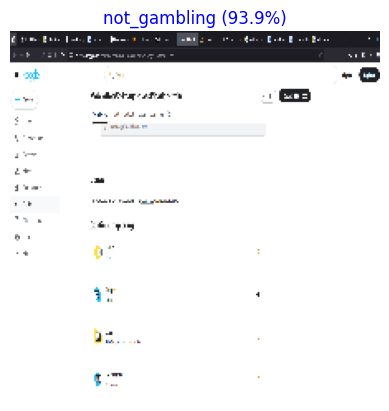

In [8]:
try:
    predict_image('../for_test/A20241001001.png', model)
    predict_image('../for_test/A20241001002.png', model)
    predict_image('../for_test/ufa-ball.png', model)
    predict_image('../for_test/de.png', model)
    predict_image('../for_test/kaggle.png', model)
except FileNotFoundError:
    print("\nError: Make sure to create a 'test_images' folder and place images in it.")
    print("Update the file paths in the script to your test images.")